# 4.Visualisations
Obj: create graphs that will visualize what was analyzed previously

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\Users\\Admin\\personal-finance-analysis\\data\\personal_transactions.csv')

df['Date'] = pd.to_datetime(df['Date'])
df['Month']   = df['Date'].dt.to_period('M')
df['Year']    = df['Date'].dt.year
df['Weekday'] = df['Date'].dt.day_name()

df_clean = df[df['Category'] != 'Credit Card Payment'].copy()
expenses = df_clean[df_clean['Transaction Type'] == 'debit'].copy()
income   = df_clean[df_clean['Transaction Type'] == 'credit'].copy()

sns.set_theme(style='whitegrid')

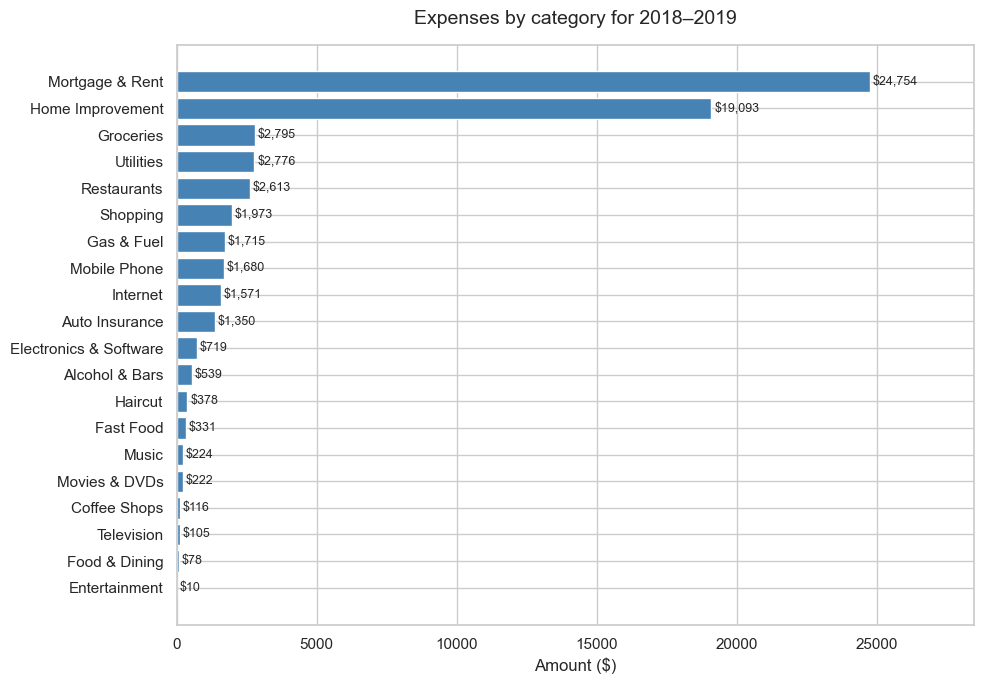

In [10]:
by_category = expenses.groupby('Category')['Amount'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(by_category.index, by_category.values, color='steelblue')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height() / 2,
            f'${width:,.0f}', va='center', fontsize=9)

ax.set_title('Expenses by category for 2018–2019', fontsize=14, pad=15)
ax.set_xlabel('Amount ($)')
ax.set_xlim(0, by_category.max() * 1.15)
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\personal-finance-analysis\\charts\\01_categories.png', dpi=150)
plt.show()

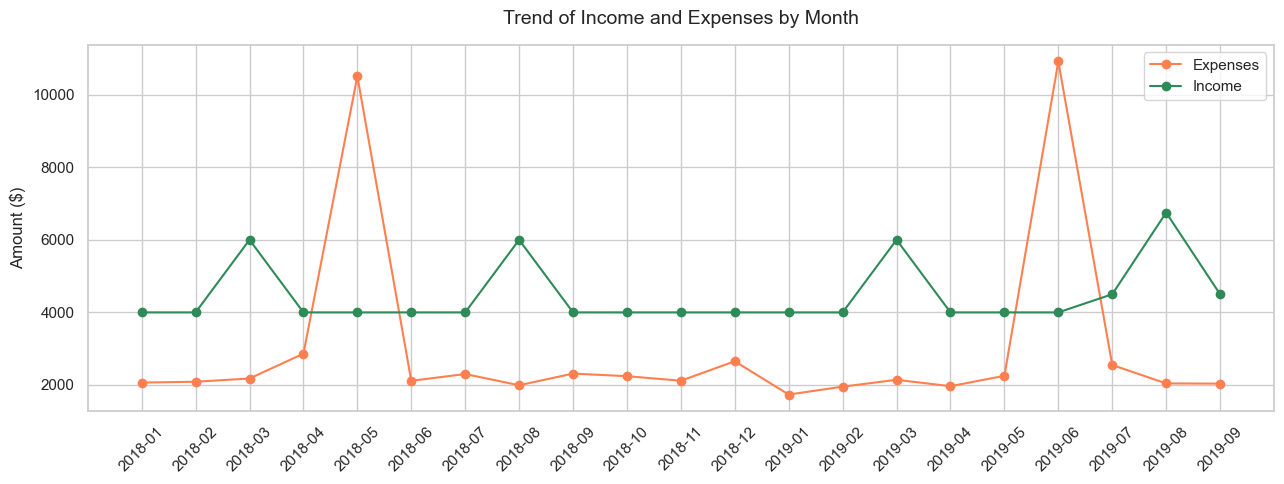

In [11]:
monthly_expenses = expenses.groupby('Month')['Amount'].sum()
monthly_income   = income.groupby('Month')['Amount'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_expenses.index.astype(str), monthly_expenses.values,
        marker='o', label='Expenses', color='coral')
ax.plot(monthly_income.index.astype(str), monthly_income.values,
        marker='o', label='Income', color='seagreen')

ax.set_title('Trend of Income and Expenses by Month', fontsize=14, pad=15)
ax.set_ylabel('Amount ($)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\personal-finance-analysis\\charts\\02_monthly_trend.png', dpi=150)
plt.show()

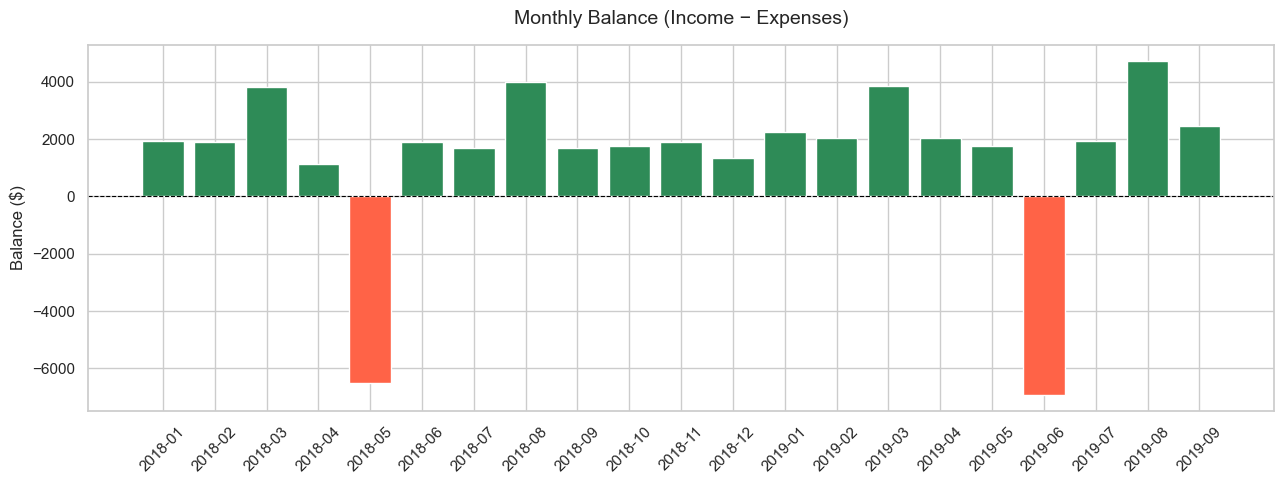

In [12]:
balance = monthly_income - monthly_expenses
colors  = ['seagreen' if x > 0 else 'tomato' for x in balance]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(balance.index.astype(str), balance.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Monthly Balance (Income − Expenses)', fontsize=14, pad=15)
ax.set_ylabel('Balance ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\personal-finance-analysis\\charts\\03_balance.png', dpi=150)
plt.show()

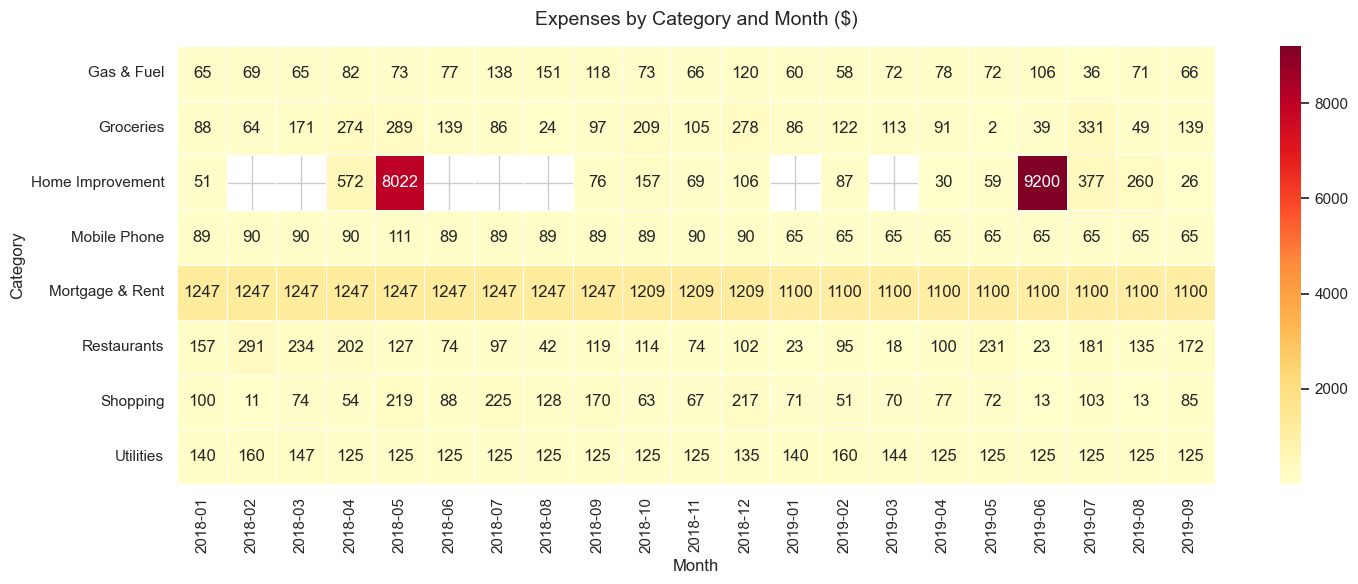

In [13]:
top8 = (expenses.groupby('Category')['Amount']
        .sum()
        .sort_values(ascending=False)
        .head(8).index)

pivot = (expenses[expenses['Category'].isin(top8)]
         .pivot_table(values='Amount', index='Category',
                      columns='Month', aggfunc='sum'))
pivot.columns = pivot.columns.astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Expenses by Category and Month ($)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\personal-finance-analysis\\charts\\04_heatmap.png', dpi=150)
plt.show()

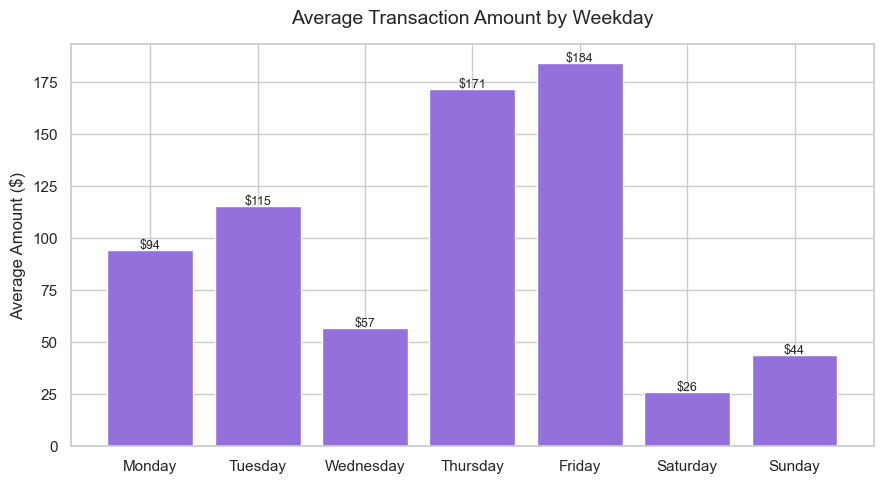

In [14]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday',
                 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_by_weekday = (expenses.groupby('Weekday')['Amount']
                  .mean()
                  .reindex(weekday_order))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(avg_by_weekday.index, avg_by_weekday.values, color='mediumpurple')

for i, val in enumerate(avg_by_weekday.values):
    ax.text(i, val + 1, f'${val:.0f}', ha='center', fontsize=9)

ax.set_title('Average Transaction Amount by Weekday', fontsize=14, pad=15)
ax.set_ylabel('Average Amount ($)')
plt.tight_layout()
plt.savefig('C:\\Users\\Admin\\personal-finance-analysis\\charts\\05_weekday.png', dpi=150)
plt.show()